In [11]:
import pandas as pd
import numpy as np 
df_original = pd.read_csv(r"C:\Users\manjo\churn-prediction\data\teleco.csv")
df = df_original.copy()

!pip install xgboost

In [12]:
 # exploring the dataset
# to check number of rows and columns
df.shape

# to check datatypes are correctly placed or not
df.dtypes

# found out that TotalCharges  must be numeric but it is string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors='coerce')

# Missing values
print(df.isnull().sum())

# there are 11 missing values in TotalCharges so fill it with values
df['TotalCharges'].fillna(0, inplace=True)

# target distribution 
print(df['Churn'].value_counts(normalize=True))

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


C:\Users\manjo\AppData\Local\Temp\ipykernel_96592\3079722562.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


Encoding

In [13]:

# 1. Gender
df['gender'] = df['gender'].map({'Male':1 , 'Female':0})

# 2. Binary columns (ONLY TRUE binary)
binary_cols = ['Partner', 'Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1 , 'No': 0})

# 3. Service columns (handle "No internet service")
service_cols = ['OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

for col in service_cols:
    df[col] = df[col].replace('No internet service', 'No')  # fix first
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Add PhoneService separately (already mapped above)
service_cols_final = ['PhoneService'] + service_cols

# 4. Create num_services
df['num_services'] = df[service_cols_final].sum(axis=1)

# 5. One-hot encoding
multi_cols = ['MultipleLines', 'InternetService',
              'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# 6. Final check
print("Shape after encoding:", df.shape)
print(df.head())
print(df.isnull().sum())  # IMPORTANT

Shape after encoding: (7043, 27)
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  7590-VHVEG       0              0        1           0       1   
1  5575-GNVDE       1              0        0           0      34   
2  3668-QPYBK       1              0        0           0       2   
3  7795-CFOCW       1              0        0           0      45   
4  9237-HQITU       0              0        0           0       2   

   PhoneService  OnlineSecurity  OnlineBackup  DeviceProtection  ...  \
0             0               0             1                 0  ...   
1             1               1             0                 1  ...   
2             1               1             1                 0  ...   
3             0               1             0                 1  ...   
4             1               0             0                 0  ...   

   num_services  MultipleLines_No phone service  MultipleLines_Yes  \
0             1                            True  

In [14]:
# dropping  the customerId column
df.drop('customerID', axis=1, inplace=True)


 Exploratory Data Analysis (EDA)

<Axes: xlabel='Contract', ylabel='count'>

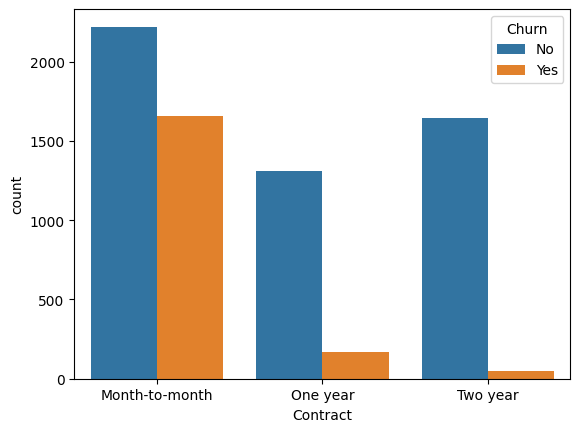

In [15]:
#Churn Rate by Contract Type
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Contract' , hue='Churn',data=df_original)

<Axes: xlabel='tenure', ylabel='Count'>

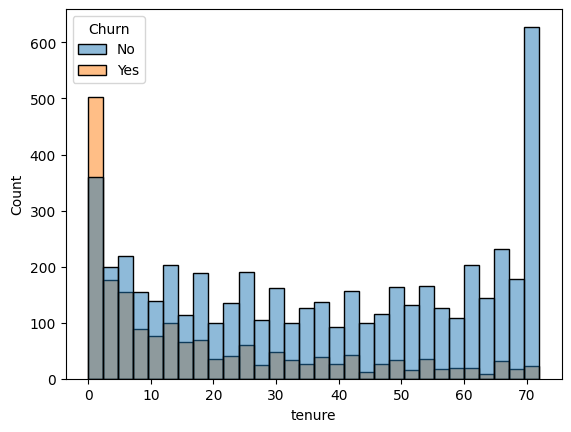

In [16]:
# tenure vs churn
sns.histplot(x='tenure' , hue='Churn' , data = df_original , bins= 30)

Monthly Charges vs Churn

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

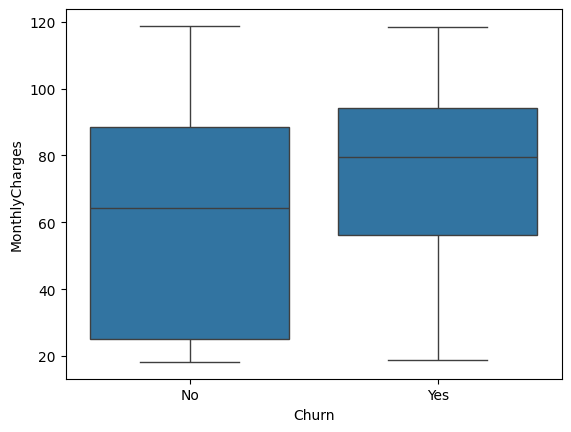

In [17]:
#Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_original)

Correlation Heatmap



<Axes: >

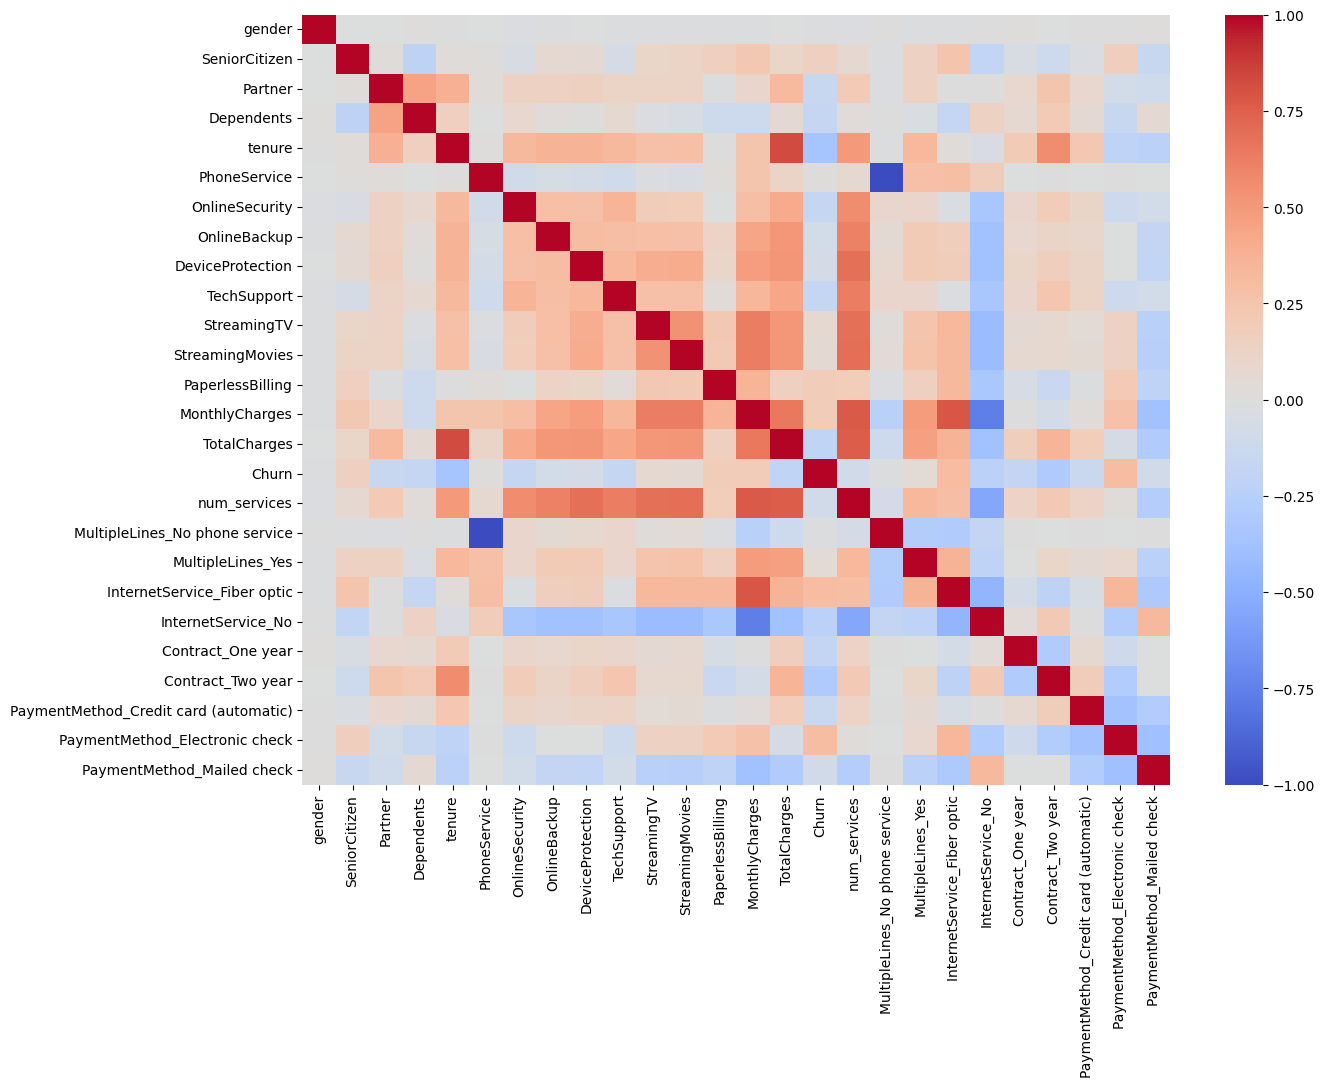

In [18]:
#Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)

In [19]:
# 1. Tenure Buckets — business-meaningful segments
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['New', 'Developing',
                                     'Mature', 'Loyal'])

# 2. Avg Monthly Value (how much per month relative to total)
df['avg_monthly_value'] = df['TotalCharges'] / (df['tenure'] + 1)

# 3. Number of services subscribed
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df['num_services'] = df[service_cols].sum(axis=1)

# 4. High value + low tenure = HIGH RISK flag
df['high_risk'] = ((df['MonthlyCharges'] > 70) &
                   (df['tenure'] < 12)).astype(int)

In [20]:
#Model building 


In [21]:
# Train test split
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis = 1)
y = df['Churn']
X = pd.get_dummies(X, drop_first=True)

X_train , X_test , y_train  , y_test = train_test_split( X , y  , test_size=0.2 , random_state = 42 , stratify=y)


In [22]:
# Scale Numerical Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# model Progression
# Baseline : Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train , y_train)

# Decision tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train , y_train)

# Random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 100 , random_state=42)
rf.fit(X_train , y_train)

#XGBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder = False , 
                   eval_metric = 'logloss',
                   random_state = 42)
xgb.fit(X_train , y_train)

#Model Evaluation
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score,
                              precision_recall_curve)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

C:\Users\manjo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:52:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.824562763181689


In [24]:
#Model Evaluation
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score,
                              precision_recall_curve)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.824562763181689


In [25]:
# model improvement
# Method 1: Class weights (simplest, always try first)
xgb = XGBClassifier(scale_pos_weight=2.77,  # ratio of neg/pos
                    random_state=42)

# Method 2: SMOTE (Synthetic Minority Oversampling)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

In [26]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rs = RandomizedSearchCV(XGBClassifier(), param_grid,
                        n_iter=20, cv=5,
                        scoring='roc_auc',
                        random_state=42)
rs.fit(X_train, y_train)
print(rs.best_params_)

{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [29]:
# train model
xgb.fit(X_train, y_train)

import pickle

pickle.dump(X.columns.tolist(), open('../models/columns.pkl', 'wb'))